Roll Number: 102303993
Calculated Parameters -> a: 0.5, b: 1.2


/tmp/ipython-input-302504623.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='latin-1')


Starting GAN training...
Epoch [2000/10000] | D Loss: 1.3987 | G Loss: 0.6566
Epoch [4000/10000] | D Loss: 1.3844 | G Loss: 0.7232
Epoch [6000/10000] | D Loss: 1.3952 | G Loss: 0.6751
Epoch [8000/10000] | D Loss: 1.3823 | G Loss: 0.6947
Epoch [10000/10000] | D Loss: 1.4211 | G Loss: 0.6705


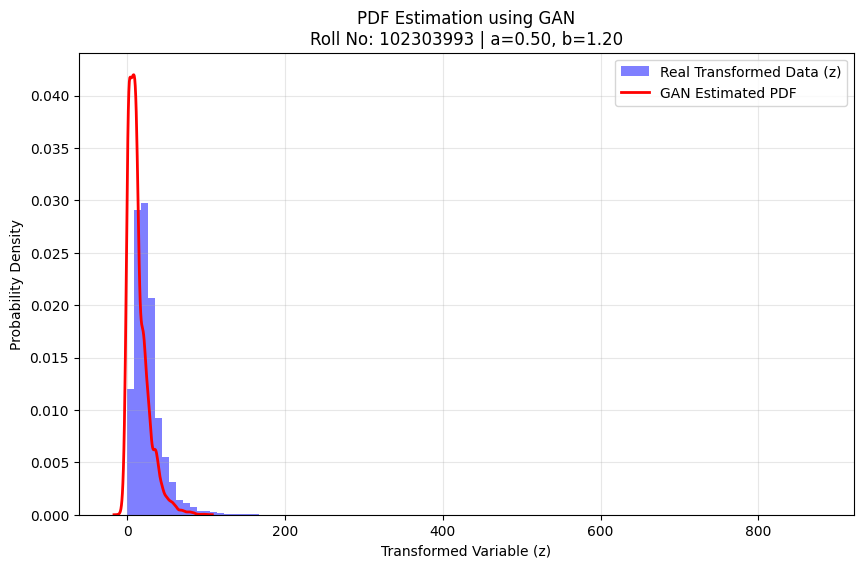

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration & Parameters ---
# Roll number as per request
ROLL_NUMBER = 102303993

# Calculate transformation parameters based on the PDF formula
# a_r = 0.5 * (r mod 7)
# b_r = 0.3 * (r mod 5 + 1)
a_val = 0.5 * (ROLL_NUMBER % 7)
b_val = 0.3 * ((ROLL_NUMBER % 5) + 1)

print(f"Roll Number: {ROLL_NUMBER}")
print(f"Calculated Parameters -> a: {a_val}, b: {b_val}")

# --- Data Loading & Transformation ---
# Load dataset (ensure data.csv is in the correct path)
# Using 'latin-1' encoding to handle potential special characters in the dataset
try:
    df = pd.read_csv('data.csv', encoding='latin-1')
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please upload the dataset.")
    # Creating dummy data just so the code structure runs if no file is present
    df = pd.DataFrame({'no2': np.random.normal(20, 5, 1000)})

# Preprocessing: Convert column to numeric and remove NaNs
raw_x = pd.to_numeric(df['no2'], errors='coerce').dropna().values

# Step-1: Transform x into z using the assignment formula
# z = x + a * sin(b * x)
z_data = raw_x + a_val * np.sin(b_val * raw_x)

# Normalize data for better GAN stability (Standard Scaling)
z_mean = z_data.mean()
z_std = z_data.std()
z_normalized = (z_data - z_mean) / z_std

# Convert to PyTorch tensor
real_data = torch.tensor(z_normalized, dtype=torch.float32).view(-1, 1)

# --- GAN Architecture ---

# Generator: Takes noise, outputs fake data
# Modified architecture: 1 -> 64 -> 128 -> 1
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

# Discriminator: Takes data, outputs probability (Real vs Fake)
# Modified architecture: 1 -> 128 -> 64 -> 1
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# --- Optimization Setup ---
lr = 0.0002
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)
criterion = nn.BCELoss()

# Training Hyperparameters
epochs = 10000
batch_size = 64

# --- Training Loop ---
print("Starting GAN training...")

for epoch in range(epochs):
    # 1. Prepare Real Data
    # Randomly sample a batch from the real dataset
    idx = torch.randint(0, len(real_data), (batch_size,))
    real_samples = real_data[idx]

    # Labels for real (1) and fake (0)
    labels_real = torch.ones(batch_size, 1)
    labels_fake = torch.zeros(batch_size, 1)

    # --- Train Discriminator ---
    optimizer_D.zero_grad()

    # Loss on real data
    output_real = discriminator(real_samples)
    loss_real = criterion(output_real, labels_real)

    # Loss on fake data
    noise = torch.randn(batch_size, 1) # Sample from N(0,1)
    fake_samples = generator(noise)
    output_fake = discriminator(fake_samples.detach()) # Detach to avoid G gradient
    loss_fake = criterion(output_fake, labels_fake)

    # Backprop D
    loss_D = loss_real + loss_fake
    loss_D.backward()
    optimizer_D.step()

    # --- Train Generator ---
    optimizer_G.zero_grad()

    # We want D to think these fake samples are real (flip labels)
    output_fake_for_G = discriminator(fake_samples)
    loss_G = criterion(output_fake_for_G, labels_real)

    # Backprop G
    loss_G.backward()
    optimizer_G.step()

    # Monitoring
    if (epoch + 1) % 2000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

# --- PDF Estimation & Visualization ---
# Step-3: Generate samples and estimate PDF
generator.eval()
with torch.no_grad():
    # Generate large number of fake samples
    noise_eval = torch.randn(10000, 1)
    generated_z_norm = generator(noise_eval).numpy()

# Denormalize data to bring it back to original scale for plotting
generated_z = (generated_z_norm * z_std) + z_mean

plt.figure(figsize=(10, 6))

# Plot Real Data Histogram
plt.hist(z_data, bins=100, density=True, alpha=0.5, color='blue', label='Real Transformed Data (z)')

# Plot Generated Data KDE (Kernel Density Estimation)
sns.kdeplot(generated_z.flatten(), color='red', linewidth=2, label='GAN Estimated PDF')

plt.title(f'PDF Estimation using GAN\nRoll No: {ROLL_NUMBER} | a={a_val:.2f}, b={b_val:.2f}')
plt.xlabel('Transformed Variable (z)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()